# The Constraint Diagram

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from ambiance import Atmosphere # this package is in metric units

a = lambda h: Atmosphere(h*0.3048).speed_of_sound * 3.2808399 # converts m/s to ft/s
rho = lambda h: Atmosphere(h*0.3047).density * 0.00194 # converts from kg/m-3 to slugs/ft-3

In [2]:
WL_range = np.linspace(0.01, 60, 500) # bound for plots, adjust if needed

CLmax = {
    'takeoff': 1.7,
    'stall': 1.5, 
    'approach': 2.0
}

AERO_DEF = {
    'AR' : 4,
    'e' : 0.95,
    'c_Do' : 0.02,
}

## The Catapult Takeoff
bing chilling equation from Raymer (5.10)
$$ W/S = \frac{1}{2} \rho (V_{end}+V_{wod}+\Delta V_{thrust})^2  \frac{C_{Lmax, takeoff}}{1.21} $$

RFP: "take-off on a tropical day (89.8 $^\circ$ F)"  
| Altitude  | Density             | Speed Units|  |
|-----------|---------------------|------------|--|
| sea level |2.19e-3 slugs/ft-3 | knots      |--|

In [39]:
def takeoff(V_end, V_wod=0, V_thrust=0, rho=2.19e-3, 
            CLmax_takeoff=CLmax['takeoff'], plot_styling={}):
    
    V_end_ft = V_end * 1.6878 # convert from kts to ft/s
    # "tropical day" density
    # engine thrust typ. 3-10 kt
    WL = 1/2 * rho * (V_end_ft + V_wod + V_thrust)**2 * CLmax_takeoff/1.21
    
    return plt.axvline(x=WL, label= f'catapult endspeed {V_end} kt', **plot_styling)

## Stall Speed
we all know this one it's also Raymer (5.6)
$$ W/S = \frac{1}{2}\rho V_{stall}^2 C_{Lmax} $$

| Altitude  | Density             | Speed Units|  |
|-----------|---------------------|------------|--|
| custom    | custom              | knots      |--|


In [4]:
def stall(V_stall, alt, rho=rho,
          CLmax=CLmax['stall'], plot_styling={}):
    rho = rho(alt)
    V = V_stall * 1.6878 # convert from kts to ft/s
    WL = 1/2 * rho * V**2 * CLmax

    return plt.axvline(x=WL, label=f"stall at {V_stall} kts, {alt/1000:.0f}k ft", **plot_styling)

## Sustained Turn
from Raymer (5.17), $ \dot{\psi}$ represents turn rate in rad/sec.
$$ \text{[deg/sec]} / 57.3 = \text{rad/sec} $$
then by Raymer (5.19),  
$$ n = \sqrt{(\frac{\dot{\psi}V}{g})^2+1} $$

$$ T/W = \frac{qC_{Do}}{W/S} + \frac{W}{S}(\frac{n^2}{q\pi e\text{AR}}) $$

| Altitude  | Density             |Input Speed Unit| a         |
|-----------|---------------------|------------|-----------|
| 20,000 ft | 1.2664e-3 slugs/ft-3| Mach       |1036.8 ft/s|


RFP Specifications  
-  **required turn rate**: 8 deg/sec  
- desired turn rate: 10 deg/sec  
- note: mid-mission fuel weight  


In [51]:
def sustained_turn(Ma, alt, deg=8.0, g=32.2, a=a, rho=rho, 
                   AR=AERO_DEF['AR'], e=AERO_DEF['e'], c_Do=AERO_DEF['c_Do'], 
                   WL=WL_range, plot_styling={}):
    a = a(alt); rho = rho(alt)
    V = Ma * a
    q = 1/2 * rho * V**2 #dynamic pressure

    turn_rate = deg/57.3 # in radians/sec
    n = np.sqrt(turn_rate * V / g) + 1


    
    TW = q * c_Do/WL + WL * (n**2)/(q*np.pi*AR*e)

    return plt.plot(WL, TW, label=f"sustained turn at {deg}$^\circ$/sec", **plot_styling)

## Dash Speed
Just a casual equilibrium where $L = W$ and $T = D$ such that when we divide the two equations we get

$$\frac{T}{W} = \frac{qSc_D}{qSc_L} =\frac{qS(c_{D0}+kc_L^2)}{qSc_L}$$

so in terms of wing loading,  
$$ \begin{gather}\frac{T}{W}=\frac{qc_{D0}}{\text{W/S}}+\frac{k}{q}\text{W/S}\end{gather}$$

where $k = \frac{1}{\pi e\text{AR}}$


Sea Level Dash  
- **required speed**: Mach 0.85  
- desirable speed: Mach 0.90
- $a$ = 1116.4 ft/s, $\rho$ = 2.377e-3 slugs/ft-3 

30,000 ft Dash  
- **required speed**: Mach 1.6  
- desirable speed: Mach 2.0 
- $a$ = 994.7 ft/s, $\rho$ = 0.8893e-3 slugs/ft-3


In [6]:
def dash(Ma, alt, a=a, rho=rho,
         e=AERO_DEF['e'], AR=AERO_DEF['AR'], c_Do=AERO_DEF['c_Do'], 
         WL=WL_range, plot_styling={},):
    a = a(alt); rho = rho(alt)
    V = Ma * a
    q = 1/2 * rho * V**2 # dynamic pressure
    k = 1/ (np.pi*e*AR)

    TW = q* c_Do / WL + k/q * WL

    return plt.plot(WL, TW, label=f"Ma {Ma} dash, {alt/1000:.0f}k ft", **plot_styling)

## Approach & Arrest
Raymer defines approach speed as 1.2x the stall speed




In [7]:
def approach(V_stall, rho=2.377e-3, CLmax_landing=2.0, plot_styling={}):
    V = V_stall * 1.6878 # convert from kts to ft/s
    WL = 1/2 * rho * (1.2*V_stall**2) * CLmax_landing

    return plt.axvline(x=WL, label=f'approach at {1.2*V_stall:.0f} kts', **plot_styling)
    

Text(0.5, 1.0, 'Constraint Diagram')

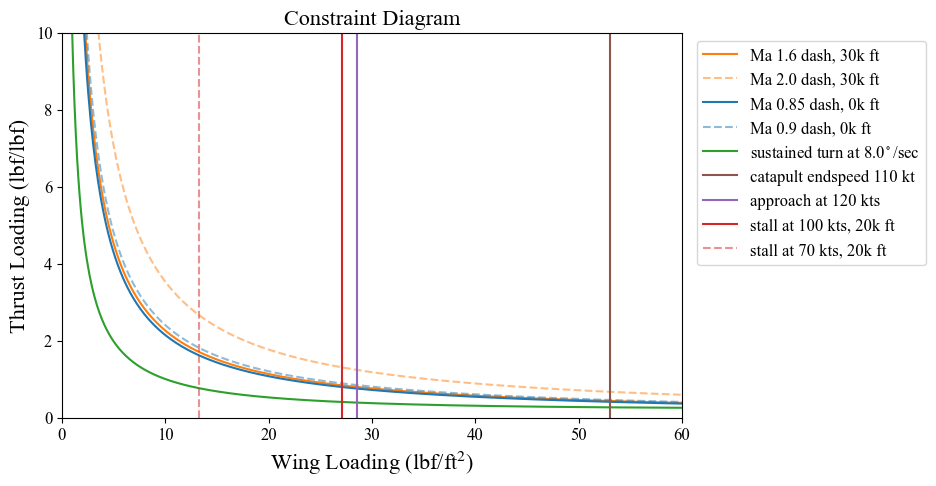

In [59]:
import matplotlib as mpl
mpl.rcParams.update({
    "font.family": "serif",
    "font.serif": ["Times New Roman"],
    "mathtext.fontset": "stix",
    "font.size": 12
})

plt.figure(figsize=(8, 5))

dash(Ma=1.6, alt=30000, 
     plot_styling={'linestyle': '-', 'color':'tab:orange'})
dash(Ma=2.0, alt=30000, 
     plot_styling={'linestyle': '--', 'color': 'tab:orange', 'alpha': 0.5})
dash(Ma=0.85, alt=0, 
     plot_styling={'linestyle': '-','color':'tab:blue'})
dash(Ma=0.90, alt=0, 
     plot_styling={'linestyle': '--','color':'tab:blue', 'alpha': 0.5})
sustained_turn(Ma=0.85, alt=20000, deg=8.0, plot_styling={'linestyle': '-', 'color': 'tab:green'})
takeoff(110,
        plot_styling={'linestyle': '-', 'color': 'tab:brown'})
approach(100,
         plot_styling={'linestyle': '-', 'color': 'tab:purple'})
stall(100, 20000,
      plot_styling={'linestyle': '-', 'color': 'tab:red'})
stall(70, 20000,
      plot_styling={'linestyle': '--', 'color': 'tab:red', 'alpha': 0.5})

plt.ylim([0, 10])
plt.xlim([0, 60])
plt.xlabel('Wing Loading (lbf/ft$^2$)', fontsize=16)
plt.ylabel('Thrust Loading (lbf/lbf)', fontsize=16)
plt.legend(bbox_to_anchor=(1.01, 1), loc='upper left')

#plt.tight_layout()
plt.title("Constraint Diagram", fontsize=16)